In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut

In [3]:
df = pd.read_csv('drive/MyDrive/GIZ_Irradiation_Project/Working Folder/models/CBE_Data/CBE_kenya.csv')

In [4]:
df.head()

,MEASURE_DATE,MEASURE_VALUE,SITE_COUNTRY,SITE_LATITUDE,SITE_LONGITUDE
0,2024-09-19,4763.700,Kenya,-0.400000,35.920000
1,2024-09-19,4243.524,Kenya,-1.494448,37.057094
2,2024-09-19,3860.330,Kenya,-1.491302,37.052862
3,2024-09-19,4764.821,Kenya,-1.451315,36.973008
4,2024-09-19,7052.209,Kenya,-0.227185,35.884984


In [5]:
df['MEASURE_DATE'] = pd.to_datetime(df['MEASURE_DATE'])
df = df.set_index('MEASURE_DATE')
df = df.sort_index()

df.head()

,MEASURE_VALUE,SITE_COUNTRY,SITE_LATITUDE,SITE_LONGITUDE
MEASURE_DATE,,,,
2017-04-01,0.0,Kenya,0.61,36.83
2017-04-02,0.0,Kenya,0.61,36.83
2017-04-03,0.0,Kenya,0.61,36.83
2017-04-04,0.0,Kenya,0.61,36.83
2017-04-05,0.0,Kenya,0.61,36.83


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 15272 entries, 2017-04-01 to 2024-11-25
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MEASURE_VALUE   15272 non-null  float64
 1   SITE_COUNTRY    15272 non-null  object 
 2   SITE_LATITUDE   15272 non-null  float64
 3   SITE_LONGITUDE  15272 non-null  float64
dtypes: float64(3), object(1)
memory usage: 596.6+ KB


In [7]:
# geolocator = Nominatim(user_agent="CBE-Kenya")

# def get_location_name(lat, lon):
#     try:
#         location = geolocator.reverse((lat, lon), exactly_one=True, timeout=10)
#         if location:
#             address = location.raw.get('address', {})
#             # Extract desired fields
#             city = address.get('city', '')
#             region = address.get('state', '')
#             return f"{city}, {region}"
#         return None
#     except GeocoderTimedOut:
#         return None


def add_unique_location_column(df, lat_col='latitude', lon_col='longitude'):
    """
    Adds a new column to the DataFrame with unique location names (e.g., 'Location 1', 'Location 2')
    based on latitude and longitude values.

    Args:
        df (pd.DataFrame): The DataFrame containing latitude and longitude columns.
        lat_col (str): Name of the column for latitude. Default is 'latitude'.
        lon_col (str): Name of the column for longitude. Default is 'longitude'.

    Returns:
        pd.DataFrame: The DataFrame with a new column 'location'.
    """
    # Create a unique identifier for each latitude-longitude pair
    unique_coords = {}
    location_counter = 1

    def get_location(lat, lon):
        nonlocal location_counter
        coord = (lat, lon)
        if coord not in unique_coords:
            unique_coords[coord] = f"Location {location_counter}"
            location_counter += 1
        return unique_coords[coord]

    df['location'] = df.apply(lambda row: get_location(row[lat_col], row[lon_col]), axis=1)
    return df

In [8]:
df_loc = add_unique_location_column(df, lat_col='SITE_LATITUDE', lon_col='SITE_LONGITUDE')


In [9]:
df_loc.head()

,MEASURE_VALUE,SITE_COUNTRY,SITE_LATITUDE,SITE_LONGITUDE,location
MEASURE_DATE,,,,,
2017-04-01,0.0,Kenya,0.61,36.83,Location 1
2017-04-02,0.0,Kenya,0.61,36.83,Location 1
2017-04-03,0.0,Kenya,0.61,36.83,Location 1
2017-04-04,0.0,Kenya,0.61,36.83,Location 1
2017-04-05,0.0,Kenya,0.61,36.83,Location 1


In [10]:
df_loc.tail()

,MEASURE_VALUE,SITE_COUNTRY,SITE_LATITUDE,SITE_LONGITUDE,location
MEASURE_DATE,,,,,
2024-11-25,1895.979,Kenya,-1.491302,37.052862,Location 13
2024-11-25,5546.946,Kenya,-0.982000,37.053900,Location 8
2024-11-25,2182.276,Kenya,-1.494448,37.057094,Location 11
2024-11-25,2213.580,Kenya,-1.494448,37.057094,Location 11
2024-11-25,4694.069,Kenya,-0.469974,35.181874,Location 3


#Plot 1

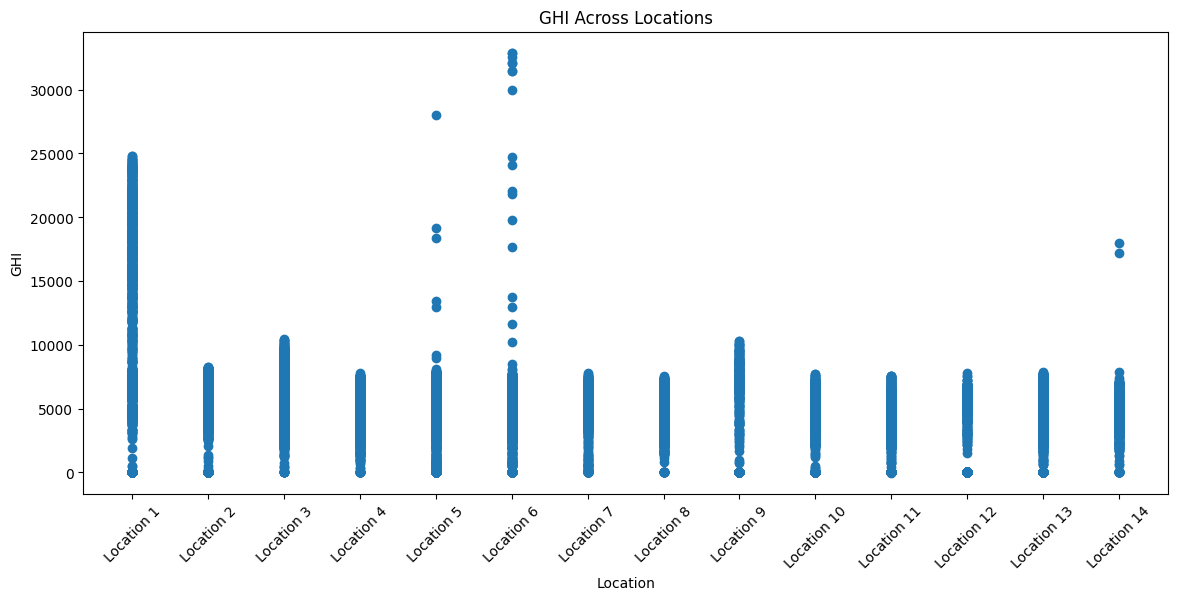

In [11]:
plt.figure(figsize=(14, 6))
plt.scatter(df['location'], df['MEASURE_VALUE'])
plt.xlabel('Location')
plt.ylabel('GHI')
plt.title('GHI Across Locations')
plt.xticks(rotation=45)
plt.show()

#Plot 2

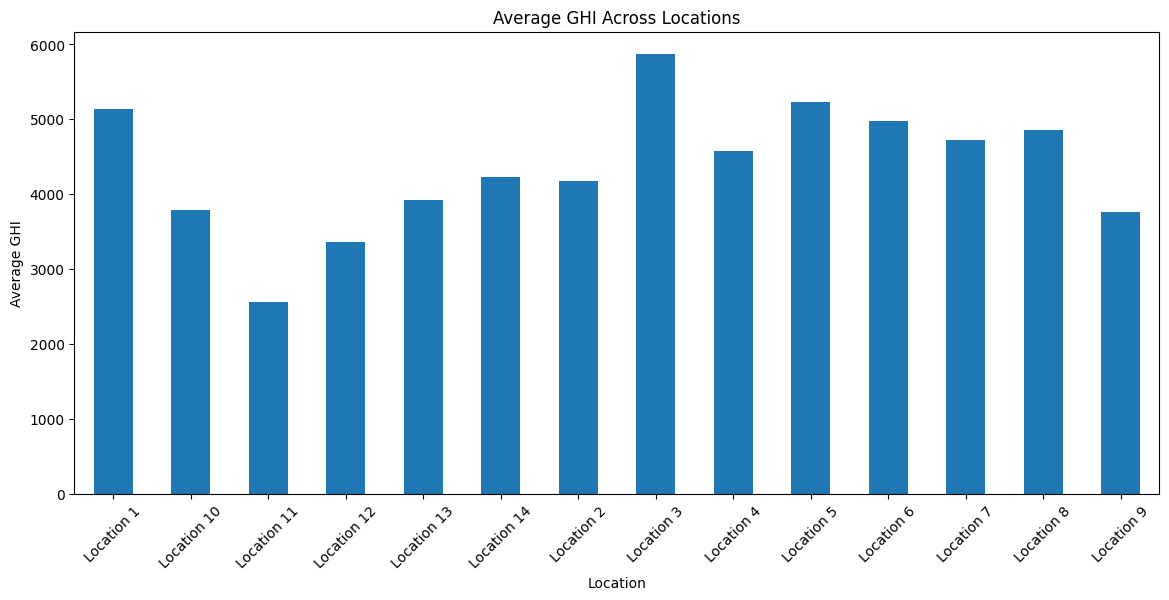

In [12]:
ghi_avg = df.groupby('location')['MEASURE_VALUE'].mean()

ghi_avg.plot(kind='bar', figsize=(14, 6))
plt.xlabel('Location')
plt.ylabel('Average GHI')
plt.title('Average GHI Across Locations')
plt.xticks(rotation=45)
plt.show()

##Box Plot

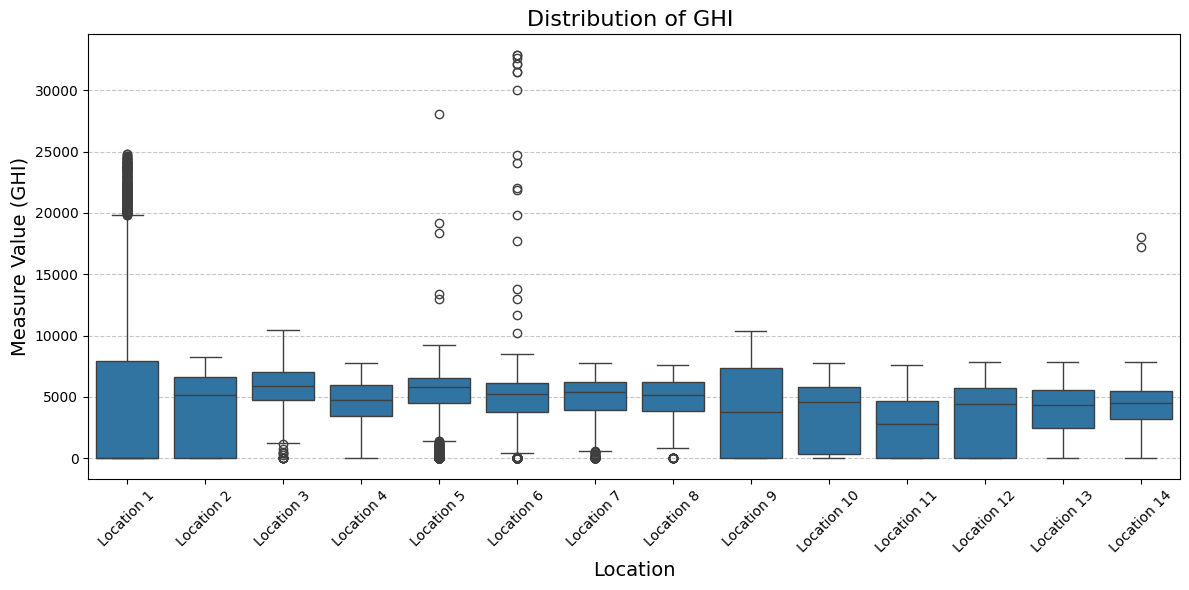

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='MEASURE_VALUE', data=df)

# Add labels and titles
plt.xlabel('Location', fontsize=14)
plt.ylabel('Measure Value (GHI)', fontsize=14)
plt.title('Distribution of GHI ', fontsize=16)
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


In [14]:
locations = df['location'].unique()


for location in locations:
    # Filter data for the current location
    location_data = df[df['location'] == location]

    # Create a new figure for each location
    plt.figure(figsize=(14, 6))
    plt.plot(location_data.index, location_data['MEASURE_VALUE'])

    # Add labels and titles
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Measure Value (GHI)', fontsize=14)
    plt.title(f'GHI plot for {location}', fontsize=16)
    plt.grid(True)
    plt.tight_layout()

    # Show the plot
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

#Adding altitude

In [15]:
import requests

In [16]:
def get_elevation(lat, lon):
    url = f"https://api.open-elevation.com/api/v1/lookup?locations={lat},{lon}"
    response = requests.get(url)
    if response.status_code == 200:
        result = response.json()['results'][0]
        return result['elevation']  # Elevation in meters
    else:
        return None

cache = {}

def get_elevation_cached(lat, lon):
    coord = (lat, lon)
    if coord not in cache:
        cache[coord] = get_elevation(lat, lon)
    return cache[coord]

In [17]:
df['elevation'] = df.apply(lambda row: get_elevation_cached(row['SITE_LATITUDE'], row['SITE_LONGITUDE']), axis=1)
df.head()

,MEASURE_VALUE,SITE_COUNTRY,SITE_LATITUDE,SITE_LONGITUDE,location,elevation
MEASURE_DATE,,,,,,
2017-04-01,0.0,Kenya,0.61,36.83,Location 1,NaN
2017-04-02,0.0,Kenya,0.61,36.83,Location 1,NaN
2017-04-03,0.0,Kenya,0.61,36.83,Location 1,NaN
2017-04-04,0.0,Kenya,0.61,36.83,Location 1,NaN
2017-04-05,0.0,Kenya,0.61,36.83,Location 1,NaN


KeyboardInterrupt: 

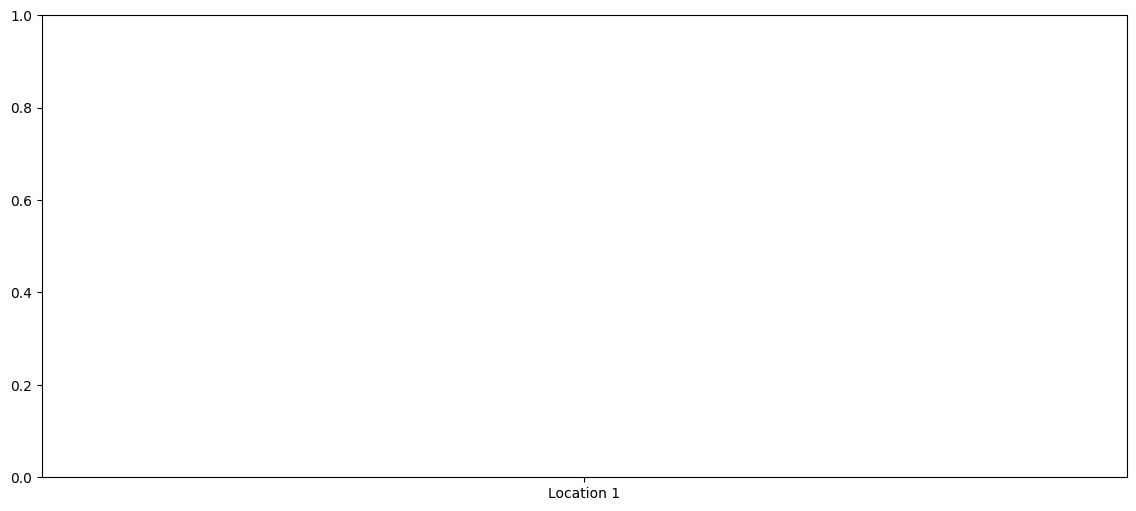

In [18]:
plt.figure(figsize=(14, 6))
bars = plt.bar(df['location'], df['elevation'], color='skyblue', edgecolor='black')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}',
             ha='center', va='bottom', fontsize=10)

plt.xlabel('Location')
plt.ylabel('Altitude (m)')
plt.title('Altitude of the Different Locations')
plt.xticks(rotation=45)
plt.show()

#Filter Dates

In [ ]:
start_date = '2020-01-01'
end_date = '2022-12-31'

# Filter the DataFrame for the date range using the index
df_filtered = df[(df.index >= start_date) & (df.index <= end_date)]

for location in locations:
    # Filter data for the current location within the date range
    location_data = df_filtered[df_filtered['location'] == location]

    # Create a new figure for each location
    plt.figure(figsize=(14, 6))

    # Use the index for the x-axis
    plt.plot(location_data.index, location_data['MEASURE_VALUE'])

    # Add labels and titles
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Measure Value (GHI)', fontsize=14)
    plt.title(f'GHI plot for {location} (2020-2022)', fontsize=16)
    plt.grid(True)
    plt.tight_layout()

    # Show the plot
    plt.show()

In [20]:
import folium

map_center = [df['SITE_LATITUDE'].mean(), df['SITE_LONGITUDE'].mean()]
ghi_map = folium.Map(location=map_center, zoom_start=6)

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['SITE_LATITUDE'], row['SITE_LONGITUDE']],
        radius=5,
        popup=f"GHI:{row['MEASURE_VALUE']}, Location: {row['location']}",
        color='blue',
        fill=True,
        fill_opacity=0.7
    ).add_to(ghi_map)

ghi_map.save('drive/MyDrive/GIZ_Irradiation_Project/Working Folder/models/CBE_Data/Location_map.html')

In [ ]:
import webbrowser

# Path to your saved map
map_path = "drive/MyDrive/GIZ_Irradiation_Project/Working Folder/models/CBE_Data/ghi_map.html"

# Open in the default browser
webbrowser.open(map_path)

##Other Parameters

In [ ]:
!ssh-keyscan -t rsa github.com >> ~/.ssh/known_hosts